# Hidden Markov Model — Synthetic Dataset Playground

This notebook generates three synthetic 1D datasets, each driven by **4 hidden states** with randomly initialized transition probabilities. The datasets are designed to test different HMM variants:

| Dataset | Emission model |
|---------|---------------|
| **A** | Distinct Gaussians |
| **B** | Distinct sinusoids (single frequency per state) |
| **C** | Distinct superpositions of many sinusoids per state |

Each dataset is a 1-D array of length **N = 500 000**.

---
After running all cells you will have:
- `obs_A`, `states_A`
- `obs_B`, `states_B`
- `obs_C`, `states_C`
- `transition_matrix` (shared by all three datasets)

The `states_*` arrays are the **ground-truth latent sequences** — use them to evaluate your models.

In [399]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

rng = np.random.default_rng(seed=42)

N        = 500_000   # total timesteps
K        = 4         # number of hidden states
PREVIEW  = 2_000     # timesteps shown in diagnostic plots

print(f"N={N:,}  K={K}")

N=500,000  K=4


## 1  Shared Markov chain

All three datasets share the same latent state sequence so results are directly comparable.

In [400]:
?rng.dirichlet

Signature: rng.dirichlet(alpha, size=None)
Docstring:
dirichlet(alpha, size=None)

Draw samples from the Dirichlet distribution.

Draw `size` samples of dimension k from a Dirichlet distribution. A
Dirichlet-distributed random variable can be seen as a multivariate
generalization of a Beta distribution. The Dirichlet distribution
is a conjugate prior of a multinomial distribution in Bayesian
inference.

Parameters
----------
alpha : sequence of floats, length k
    Parameter of the distribution (length ``k`` for sample of
    length ``k``).
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n)``, then
    ``m * n * k`` samples are drawn.  Default is None, in which case a
    vector of length ``k`` is returned.

Returns
-------
samples : ndarray,
    The drawn samples, of shape ``(size, k)``.

Raises
------
ValueError
    If any value in ``alpha`` is less than zero

Notes
-----
The Dirichlet distribution is a distribution over vectors
:math:`x` t

In [401]:
def random_transition_matrix(k, rng, concentration=10.0):
    """
    Sample a K×K row-stochastic transition matrix from a Dirichlet distribution.
    `concentration` > 1 makes transitions smoother (less self-loops dominate).
    """
    A = rng.dirichlet(np.full(k, concentration), size=k)
    return A


def sample_markov_chain(A, n, rng, pi0=None):
    """
    Draw a length-n state sequence from an HMM with transition matrix A.
    pi0 : initial state distribution (uniform if None)
    """
    k = A.shape[0]
    if pi0 is None:
        pi0 = np.ones(k) / k

    states = np.empty(n, dtype=np.int32)
    states[0] = rng.choice(k, p=pi0)
    for t in range(1, n):
        states[t] = rng.choice(k, p=A[states[t - 1]])
    return states


# --- build the shared chain ---
transition_matrix = random_transition_matrix(K, rng, concentration=0.5)

print("Transition matrix (rows = from-state, cols = to-state):")
print(np.round(transition_matrix, 3))

# Stationary distribution (dominant left eigenvector)
eigvals, eigvecs = np.linalg.eig(transition_matrix.T)
stat = np.real(eigvecs[:, np.argmax(np.real(eigvals))])
stat /= stat.sum()
print(f"\nStationary distribution: {np.round(stat, 3)}")

# Sample once — reused for all datasets
states = sample_markov_chain(transition_matrix, N, rng)
print(f"\nState sequence shape: {states.shape}")
print(f"Empirical state frequencies: {np.round(np.bincount(states) / N, 3)}")

Transition matrix (rows = from-state, cols = to-state):
[[0.282 0.449 0.003 0.265]
 [0.018 0.151 0.491 0.341]
 [0.169 0.118 0.583 0.13 ]
 [0.023 0.666 0.101 0.21 ]]

Stationary distribution: [0.106 0.284 0.389 0.222]

State sequence shape: (500000,)
Empirical state frequencies: [0.106 0.284 0.389 0.221]


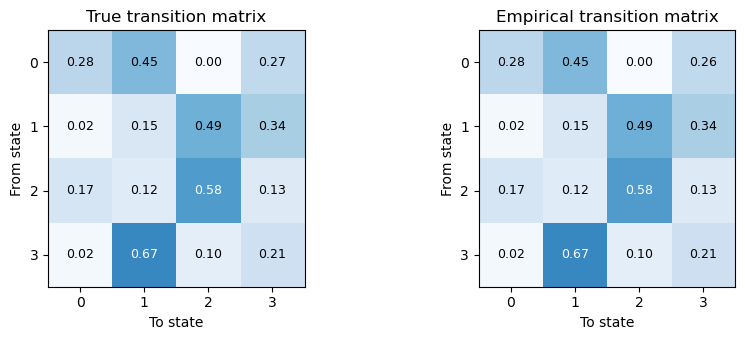

In [402]:
# Quick sanity-check: empirical transition matrix
emp_A = np.zeros((K, K))
for t in range(N - 1):
    emp_A[states[t], states[t + 1]] += 1
emp_A /= emp_A.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, mat, title in zip(axes,
                           [transition_matrix, emp_A],
                           ["True transition matrix", "Empirical transition matrix"]):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("To state")
    ax.set_ylabel("From state")
    ax.set_xticks(range(K))
    ax.set_yticks(range(K))
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center",
                    color="white" if mat[i, j] > 0.5 else "black", fontsize=9)
plt.tight_layout()
plt.show()

## 2  Dataset A — Gaussian emissions

Each of the 4 states emits from a distinct Gaussian $\mathcal{N}(\mu_k, \sigma_k^2)$.

Means are spread across $[-6, -2, 2, 6]$ with small noise added; standard deviations are all 0.8.

In [403]:
# --- Gaussian emission parameters ---
gauss_means  = np.array([-6.0, -2.0, 2.0, 6.0])  # one per state
gauss_stds   = np.array([ 0.8,  0.8, 0.8, 0.8])

obs_A = rng.normal(loc=gauss_means[states], scale=gauss_stds[states]).astype(np.float32)
states_A = states.copy()

print(f"obs_A  shape: {obs_A.shape}  dtype: {obs_A.dtype}")
print(f"obs_A  range: [{obs_A.min():.2f}, {obs_A.max():.2f}]")

obs_A  shape: (500000,)  dtype: float32
obs_A  range: [-9.18, 9.30]


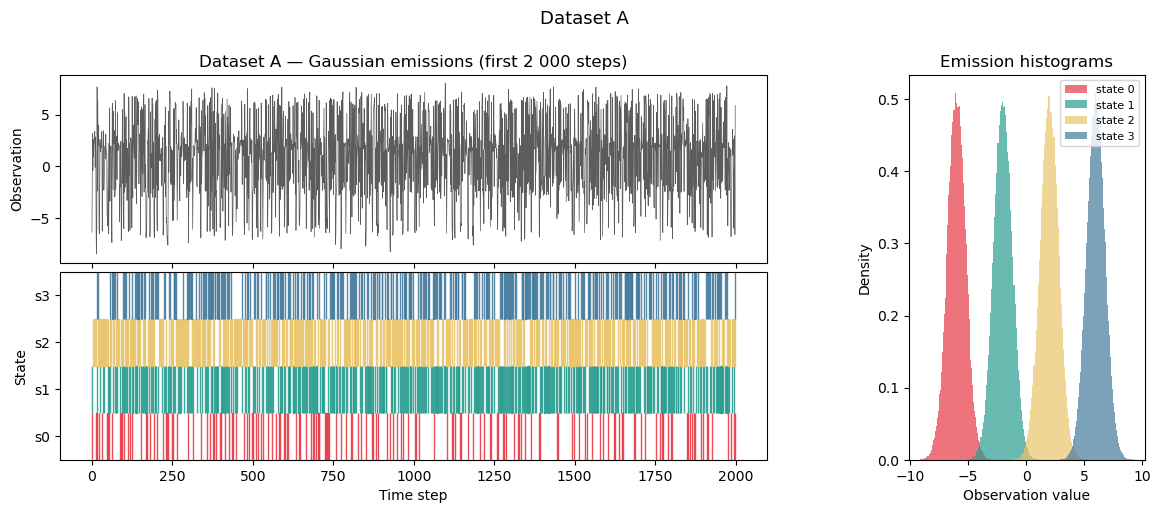

In [404]:
STATE_COLORS = ["#E63946", "#2A9D8F", "#E9C46A", "#457B9D"]
cmap4 = ListedColormap(STATE_COLORS)

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(2, 2, width_ratios=[3, 1], hspace=0.05, wspace=0.3)

ax_ts  = fig.add_subplot(gs[0, 0])
ax_st  = fig.add_subplot(gs[1, 0], sharex=ax_ts)
ax_hist = fig.add_subplot(gs[:, 1])

t = np.arange(PREVIEW)
ax_ts.plot(t, obs_A[:PREVIEW], lw=0.5, color="#333", alpha=0.8)
ax_ts.set_ylabel("Observation")
ax_ts.set_title("Dataset A — Gaussian emissions (first 2 000 steps)")
ax_ts.tick_params(labelbottom=False)

for k in range(K):
    mask = states_A[:PREVIEW] == k
    ax_st.fill_between(t, k, k + 1, where=mask, color=STATE_COLORS[k], alpha=0.9)
ax_st.set_ylim(0, K)
ax_st.set_yticks(np.arange(K) + 0.5)
ax_st.set_yticklabels([f"s{k}" for k in range(K)])
ax_st.set_xlabel("Time step")
ax_st.set_ylabel("State")

for k in range(K):
    ax_hist.hist(obs_A[states_A == k], bins=80, density=True,
                 color=STATE_COLORS[k], alpha=0.7, label=f"state {k}")
ax_hist.set_xlabel("Observation value")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Emission histograms")
ax_hist.legend(fontsize=8)

plt.suptitle("Dataset A", fontsize=13, y=1.01)
plt.show()

## 3  Dataset B — Single sinusoid per state

Each state emits samples from a **sinusoid with a distinct frequency and phase**, plus Gaussian noise:

$$x_t = A_k \sin(2\pi f_k\, t + \phi_k) + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma^2)$$

The *phase is global* (it keeps running even while the state is inactive), so state transitions create characteristic discontinuities.

In [405]:
from scipy.signal import savgol_filter
# --- Sinusoid emission parameters ---
sin_freqs  = np.array([0.005, 0.020, 0.060, 0.150])   # cycles / sample
sin_amps   = np.array([2.0,   2.0,   2.0,   2.0])
sin_noise  = 0.25   # additive Gaussian noise std

# 1. Map each time step to its instantaneous frequency based on the current state
step_freqs = sin_freqs[states]

# 2. Calculate the phase increment for each step (radians per sample)
phase_increments = 2 * np.pi * step_freqs

# 3. Accumulate the phase continuously and add a single random starting offset
initial_phase = rng.uniform(0, 2 * np.pi)
continuous_phases = np.cumsum(phase_increments) + initial_phase

# Map amplitudes dynamically (if they were different, though here they are all 2.0)
step_amps = sin_amps[states]

# Generate continuous observations with additive noise
obs_B = (step_amps * np.sin(continuous_phases) + rng.normal(0, sin_noise, size=N)).astype(np.float32)
states_B = states.copy()

print(f"obs_B  shape: {obs_B.shape}  dtype: {obs_B.dtype}")
print(f"obs_B  range: [{obs_B.min():.2f}, {obs_B.max():.2f}]")
print(f"\nSinusoid frequencies (cycles/sample): {sin_freqs}")
print(f"Global starting phase (rad):            {np.round(initial_phase, 3)}")

obs_B  shape: (500000,)  dtype: float32
obs_B  range: [-3.01, 3.12]

Sinusoid frequencies (cycles/sample): [0.005 0.02  0.06  0.15 ]
Global starting phase (rad):            1.779


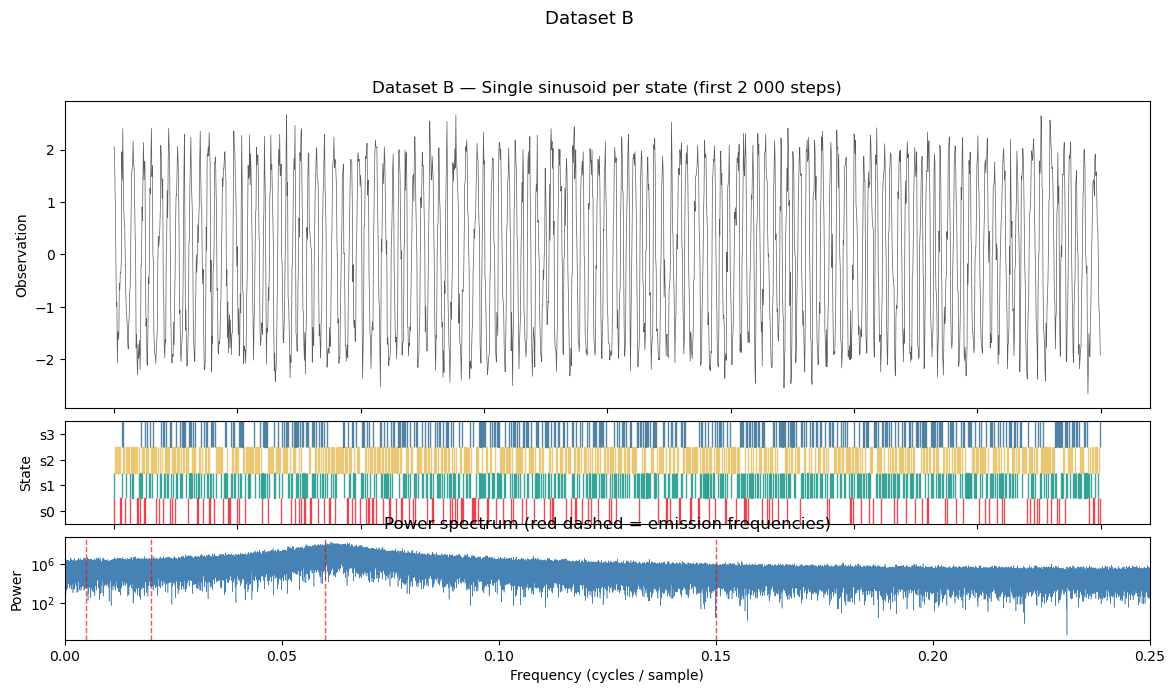

In [406]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7),
                          gridspec_kw={"height_ratios": [3, 1, 1], "hspace": 0.08})

t_slice = np.arange(PREVIEW)

axes[0].plot(t_slice, obs_B[:PREVIEW], lw=0.5, color="#333", alpha=0.8)
axes[0].set_ylabel("Observation")
axes[0].set_title("Dataset B — Single sinusoid per state (first 2 000 steps)")
axes[0].tick_params(labelbottom=False)

# Show the underlying noiseless sinusoids for reference
# for k in range(K):
#     axes[0].plot(t_slice, sin_signals[:PREVIEW, k],
#                  lw=1.2, color=STATE_COLORS[k], alpha=0.5,
#                  label=f"state {k}  f={sin_freqs[k]}")
# axes[0].legend(fontsize=8, loc="upper right")

for k in range(K):
    mask = states_B[:PREVIEW] == k
    axes[1].fill_between(t_slice, k, k + 1, where=mask, color=STATE_COLORS[k], alpha=0.9)
axes[1].set_ylim(0, K)
axes[1].set_yticks(np.arange(K) + 0.5)
axes[1].set_yticklabels([f"s{k}" for k in range(K)])
axes[1].set_ylabel("State")
axes[1].tick_params(labelbottom=False)

# Power spectrum
freqs = np.fft.rfftfreq(N)
psd   = np.abs(np.fft.rfft(obs_B.astype(np.float64))) ** 2
axes[2].semilogy(freqs, psd, lw=0.4, color="steelblue")
for f in sin_freqs:
    axes[2].axvline(f, color="red", lw=1.0, alpha=0.7, linestyle="--")
axes[2].set_xlim(0, 0.25)
axes[2].set_xlabel("Frequency (cycles / sample)")
axes[2].set_ylabel("Power")
axes[2].set_title("Power spectrum (red dashed = emission frequencies)")

plt.suptitle("Dataset B", fontsize=13, y=1.01)
plt.show()

## 4  Dataset C — Superposition of many sinusoids per state

Each state emits the sum of **M = 12 sinusoids** with randomly drawn frequencies, amplitudes, and phases:

$$x_t = \sum_{m=1}^{M} a_{k,m} \sin(2\pi f_{k,m}\, t + \phi_{k,m}) + \epsilon_t$$

The spectral fingerprints of the four states are distinct but individually complex, making this a harder inference problem — motivating the AR-HMM and factorial HMM.

In [407]:
M_COMPONENTS = 12

# Draw per-state, per-component parameters
super_freqs   = rng.uniform(0.002, 0.25,      size=(K, M_COMPONENTS))
super_amps    = rng.exponential(scale=0.5,    size=(K, M_COMPONENTS))
super_noise   = 0.05

# Normalize amplitudes so each state's ideal signal has unit variance.
# The variance of a sum of M independent sinusoids is sum(A_m^2 / 2).
state_vars = np.sum(super_amps**2, axis=1) / 2.0
super_amps = super_amps / np.sqrt(state_vars[:, None])

# 1. Map time steps to the instantaneous frequencies and amplitudes for the M oscillators
step_freqs = super_freqs[states]  # Shape: (N, M)
step_amps  = super_amps[states]   # Shape: (N, M)

# 2. Calculate phase increments and accumulate continuously
phase_increments = 2 * np.pi * step_freqs
initial_phases = rng.uniform(0, 2 * np.pi, size=M_COMPONENTS)
continuous_phases = np.cumsum(phase_increments, axis=0) + initial_phases

# 3. Generate the continuous superimposed signal by summing across the M oscillators
super_signal = np.sum(step_amps * np.sin(continuous_phases), axis=1)

# 4. Add noise
obs_C = (super_signal + rng.normal(0, super_noise, size=N)).astype(np.float32)
states_C = states.copy()

print(f"obs_C  shape: {obs_C.shape}  dtype: {obs_C.dtype}")
print(f"obs_C  range: [{obs_C.min():.2f}, {obs_C.max():.2f}]")

obs_C  shape: (500000,)  dtype: float32
obs_C  range: [-3.39, 3.79]


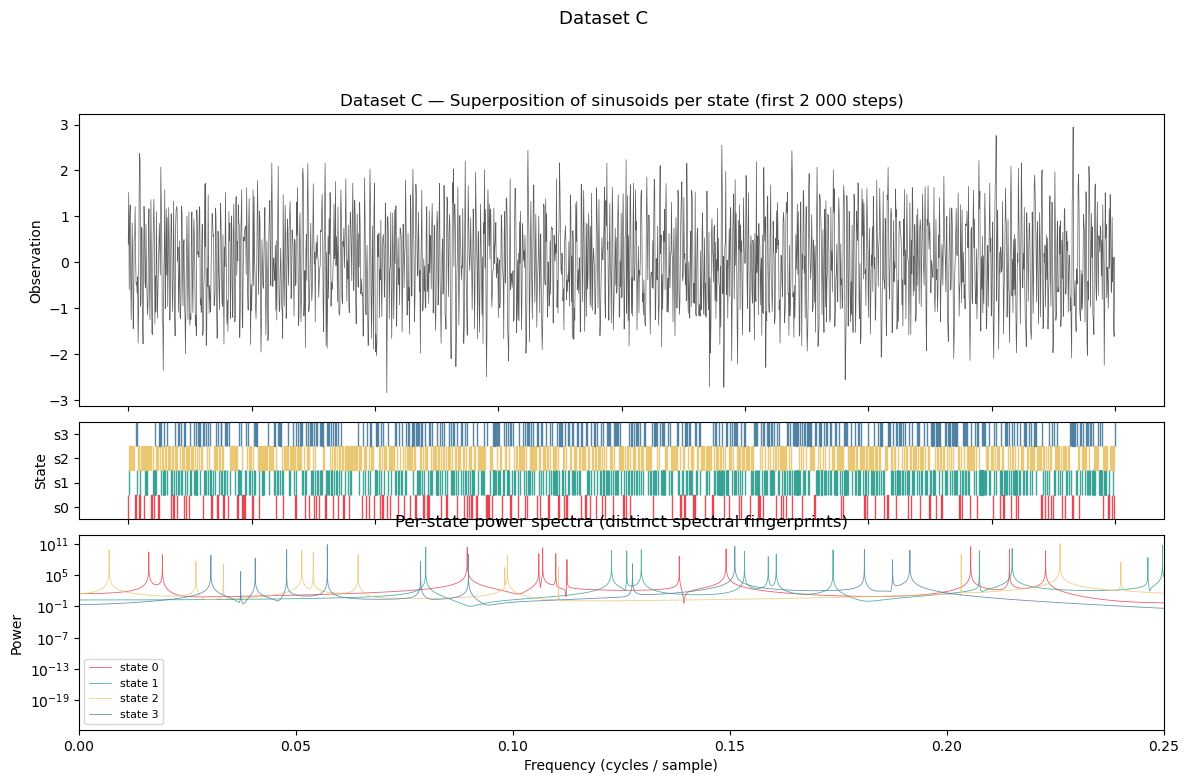

In [408]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8),
                          gridspec_kw={"height_ratios": [3, 1, 2], "hspace": 0.08})

t_slice = np.arange(PREVIEW)

axes[0].plot(t_slice, obs_C[:PREVIEW], lw=0.5, color="#333", alpha=0.8)
axes[0].set_ylabel("Observation")
axes[0].set_title("Dataset C — Superposition of sinusoids per state (first 2 000 steps)")
axes[0].tick_params(labelbottom=False)

for k in range(K):
    mask = states_C[:PREVIEW] == k
    axes[1].fill_between(t_slice, k, k + 1, where=mask,
                         color=STATE_COLORS[k], alpha=0.9)
axes[1].set_ylim(0, K)
axes[1].set_yticks(np.arange(K) + 0.5)
axes[1].set_yticklabels([f"s{k}" for k in range(K)])
axes[1].set_ylabel("State")
axes[1].tick_params(labelbottom=False)

# Per-state PSDs
freqs = np.fft.rfftfreq(N)
for k in range(K):
    sig_k = super_signals[:, k]
    psd_k = np.abs(np.fft.rfft(sig_k)) ** 2
    axes[2].semilogy(freqs, psd_k, lw=0.6,
                     color=STATE_COLORS[k], alpha=0.8, label=f"state {k}")
axes[2].set_xlim(0, 0.25)
axes[2].set_xlabel("Frequency (cycles / sample)")
axes[2].set_ylabel("Power")
axes[2].set_title("Per-state power spectra (distinct spectral fingerprints)")
axes[2].legend(fontsize=8)

plt.suptitle("Dataset C", fontsize=13, y=1.01)
plt.show()

## 5  Save datasets

Everything is saved into a single compressed `.npz` archive for easy loading downstream.

In [409]:
np.savez_compressed(
    "hmm_datasets.npz",
    # observations
    obs_A=obs_A,
    obs_B=obs_B,
    obs_C=obs_C,
    # ground-truth latents
    states_A=states_A,
    states_B=states_B,
    states_C=states_C,
    # generative parameters
    transition_matrix=transition_matrix,
    gauss_means=gauss_means,
    gauss_stds=gauss_stds,
    sin_freqs=sin_freqs,
    sin_amps=sin_amps,
    sin_phases=sin_phases,
    super_freqs=super_freqs,
    super_amps=super_amps,
    super_phases=super_phases,
)
print("Saved → hmm_datasets.npz")

# Quick reload sanity check
d = np.load("hmm_datasets.npz")
print("Keys in archive:", sorted(d.keys()))
print("obs_A[:5]  :", d["obs_A"][:5])
print("states_A[:5]:", d["states_A"][:5])

Saved → hmm_datasets.npz
Keys in archive: ['gauss_means', 'gauss_stds', 'obs_A', 'obs_B', 'obs_C', 'sin_amps', 'sin_freqs', 'sin_phases', 'states_A', 'states_B', 'states_C', 'super_amps', 'super_freqs', 'super_phases', 'transition_matrix']
obs_A[:5]  : [-6.362267   -1.4095645   3.1732183  -0.41209754  2.588429  ]
states_A[:5]: [0 1 2 2 2]


## 6  Summary statistics

Quick table of per-dataset, per-state statistics to keep handy while implementing your models.

In [410]:
print("=" * 60)
print("DATASET A — Gaussian emissions")
print("=" * 60)
for k in range(K):
    v = obs_A[states_A == k]
    print(f"  State {k}: true μ={gauss_means[k]:+.1f}  "
          f"empirical μ={v.mean():+.3f}  σ={v.std():.3f}  n={len(v):,}")

print()
print("=" * 60)
print("DATASET B — Single sinusoid per state")
print("=" * 60)
for k in range(K):
    v = obs_B[states_B == k]
    print(f"  State {k}: f={sin_freqs[k]:.3f} cyc/samp  "
          f"empirical μ={v.mean():+.3f}  σ={v.std():.3f}  n={len(v):,}")

print()
print("=" * 60)
print("DATASET C — Superposition of sinusoids per state")
print("=" * 60)
for k in range(K):
    v = obs_C[states_C == k]
    print(f"  State {k}: {M_COMPONENTS} components  "
          f"empirical μ={v.mean():+.3f}  σ={v.std():.3f}  n={len(v):,}")

print()
print("Transition matrix:")
print(np.round(transition_matrix, 4))

DATASET A — Gaussian emissions
  State 0: true μ=-6.0  empirical μ=-5.998  σ=0.795  n=53,032
  State 1: true μ=-2.0  empirical μ=-1.998  σ=0.802  n=142,004
  State 2: true μ=+2.0  empirical μ=+2.002  σ=0.800  n=194,466
  State 3: true μ=+6.0  empirical μ=+5.996  σ=0.801  n=110,498

DATASET B — Single sinusoid per state
  State 0: f=0.005 cyc/samp  empirical μ=+0.009  σ=1.434  n=53,032
  State 1: f=0.020 cyc/samp  empirical μ=-0.003  σ=1.433  n=142,004
  State 2: f=0.060 cyc/samp  empirical μ=+0.003  σ=1.437  n=194,466
  State 3: f=0.150 cyc/samp  empirical μ=-0.001  σ=1.437  n=110,498

DATASET C — Superposition of sinusoids per state
  State 0: 12 components  empirical μ=-0.003  σ=1.002  n=53,032
  State 1: 12 components  empirical μ=-0.002  σ=1.005  n=142,004
  State 2: 12 components  empirical μ=+0.004  σ=1.002  n=194,466
  State 3: 12 components  empirical μ=-0.001  σ=1.001  n=110,498

Transition matrix:
[[0.2823 0.4493 0.0031 0.2652]
 [0.018  0.1505 0.4909 0.3406]
 [0.1688 0.118  0

---
## 7  Your model implementations go here

Below are placeholder cells for the three model classes. Each block loads the data from the archive, so models can be developed independently.

### 7.1  Standard HMM

Implement the forward-backward algorithm (Baum-Welch) or Viterbi decoding.  
Suggested emission family for each dataset:
- **A** → Gaussian
- **B** → Gaussian (use the raw observation; the model must infer phase from context)
- **C** → Gaussian (same note — the spectral complexity is baked into the obs)

In [411]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.stats.norm as jnorm

d = np.load("hmm_datasets.npz")
obs    = d["obs_A"]
states = d["states_A"]

def viterbi_decode(obs, pi, A, mu, var):
    """Predicts the most likely sequence of hidden states using the Viterbi algorithm in log-space."""
    # Add epsilon to prevent log(0)
    log_pi = jnp.log(pi + 1e-10)
    log_A = jnp.log(A + 1e-10)
    
    def viterbi_step(prev_v, obs_t):
        log_emissions = jnorm.logpdf(obs_t, mu, jnp.sqrt(var))
        
        # paths[j, k] represents the log probability of transitioning from state j to k
        paths = prev_v[:, None] + log_A
        
        max_v = jnp.max(paths, axis=0) + log_emissions
        argmax_v = jnp.argmax(paths, axis=0)
        
        return max_v, argmax_v

    # Initialization at t=0
    log_emissions_0 = jnorm.logpdf(obs[0], mu, jnp.sqrt(var))
    v_0 = log_pi + log_emissions_0
    
    # Forward pass mapping probabilities and collecting backpointers
    final_v, backpointers = jax.lax.scan(viterbi_step, v_0, obs[1:])
    
    # Traceback initialization
    best_last_state = jnp.argmax(final_v)
    
    # Backward pass to reconstruct the optimal sequence
    def backtrack_step(next_state, bp_t):
        curr_state = bp_t[next_state]
        return curr_state, curr_state

    _, rev_path = jax.lax.scan(backtrack_step, best_last_state, backpointers[::-1])
    
    # Append the final state and reverse the sequence to chronological order
    path = jnp.append(rev_path[::-1], best_last_state)
    return path

@jax.jit
def em_step(obs, pi, A, mu, var):
    """Executes a single E-M step compiled via XLA."""
    N = len(pi)

    # --- E-Step: Forward Pass ---
    def forward_step(alpha_prev, obs_t):
        emissions = jnorm.pdf(obs_t, mu, jnp.sqrt(var))
        alpha_unscaled = jnp.dot(alpha_prev, A) * emissions
        c_t = 1.0 / jnp.sum(alpha_unscaled)
        alpha_t = alpha_unscaled * c_t
        return alpha_t, (alpha_t, c_t)

    emissions_0 = jnorm.pdf(obs[0], mu, jnp.sqrt(var))
    alpha_0_unscaled = pi * emissions_0
    c_0 = 1.0 / jnp.sum(alpha_0_unscaled)
    alpha_0 = alpha_0_unscaled * c_0

    _, (alphas_rest, cs_rest) = jax.lax.scan(forward_step, alpha_0, obs[1:])
    alpha = jnp.vstack([alpha_0, alphas_rest])
    c = jnp.append(c_0, cs_rest)
    ll = -jnp.sum(jnp.log(c))

    # --- E-Step: Backward Pass ---
    def backward_step(beta_next, inputs):
        obs_next, c_t = inputs
        emissions_next = jnorm.pdf(obs_next, mu, jnp.sqrt(var))
        beta_t = jnp.dot(A, emissions_next * beta_next) * c_t
        return beta_t, beta_t

    beta_T = jnp.ones(N) * c[-1]
    
    _, betas_rev = jax.lax.scan(
        backward_step, 
        beta_T, 
        (obs[1:][::-1], c[:-1][::-1])
    )
    beta = jnp.vstack([betas_rev[::-1], beta_T])

    # --- E-Step: Gamma and Xi ---
    gamma = alpha * beta
    gamma = gamma / jnp.sum(gamma, axis=1, keepdims=True)

    def xi_step(inputs):
        alpha_t, obs_next, beta_next = inputs
        emissions = jnorm.pdf(obs_next, mu, jnp.sqrt(var))
        xi_t = alpha_t[:, None] * A * emissions[None, :] * beta_next[None, :]
        return xi_t / jnp.sum(xi_t)
    
    xi = jax.vmap(xi_step)((alpha[:-1], obs[1:], beta[1:]))

    # --- M-Step ---
    pi_new = gamma[0]
    A_new = jnp.sum(xi, axis=0) / jnp.sum(gamma[:-1], axis=0)[:, None]
    
    mu_new = jnp.sum(gamma * obs[:, None], axis=0) / jnp.sum(gamma, axis=0)
    
    obs_diff = obs[:, None] - mu_new[None, :]
    var_new = jnp.sum(gamma * (obs_diff ** 2), axis=0) / jnp.sum(gamma, axis=0)

    return pi_new, A_new, mu_new, var_new, ll

def baum_welch(obs, n_states=4, n_iter=100, tol=1e-4):
    """Outer loop for fitting HMM parameters."""
    N = n_states
    
    # Initialization using numpy (outside JIT)
    obs_np = np.array(obs)
    pi = jnp.ones(N) / N
    A = jnp.ones((N, N)) / N
    
    percentiles = np.linspace(0, 100, N+2)[1:-1]
    mu = jnp.array(np.percentile(obs_np, percentiles))
    var = jnp.ones(N) * np.var(obs_np) / N
    
    prev_ll = -jnp.inf
    
    for _ in range(n_iter):
        pi, A, mu, var, ll = em_step(obs, pi, A, mu, var)
        
        if jnp.abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
        
    return pi, A, mu, var, ll




In [412]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
def align_states(true_states, pred_states):
    """Aligns unsupervised predicted states to ground truth labels."""
    # Convert JAX arrays to standard NumPy arrays
    pred_states = np.array(pred_states)
    true_states = np.array(true_states)
    
    cm = confusion_matrix(true_states, pred_states)
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
    
    # Vectorized mapping
    aligned_preds = np.zeros_like(pred_states)
    for true_label, pred_label in zip(row_ind, col_ind):
        aligned_preds[pred_states == pred_label] = true_label
        
    return aligned_preds

In [413]:
est_pi, est_A, est_mu, est_var, final_ll = baum_welch(d['obs_A'], n_states=4)
 
predicted_states = viterbi_decode(d['obs_A'], est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(d['states_A'],predicted_states) == d['states_A'])
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

0.993976
[1.0000000e+000 3.0581147e-131 0.0000000e+000 0.0000000e+000] [[0.28038268 0.45168865 0.00322686 0.26470181]
 [0.018211   0.15083701 0.4941745  0.3367775 ]
 [0.17034244 0.11816845 0.58145823 0.13003088]
 [0.02217711 0.66663746 0.10015007 0.21103536]] [-5.99794427 -1.99784303  2.00214028  5.99647293] [0.63193866 0.64327396 0.63991484 0.64063414] -1120965.36101434


In [414]:
est_pi, est_A, est_mu, est_var, final_ll = baum_welch(d['obs_B'], n_states=4)
 
predicted_states = viterbi_decode(d['obs_B'], est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(d['states_B'],predicted_states) == d['states_B'])
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

0.269848
[0.00000000e+000 0.00000000e+000 1.54885722e-213 1.00000000e+000] [[7.67162575e-001 2.22425577e-001 1.04118483e-002 3.04259847e-113]
 [2.85094595e-001 4.31055411e-001 2.70226831e-001 1.36231633e-002]
 [1.44579143e-002 2.70754422e-001 4.26003498e-001 2.88784166e-001]
 [1.10156050e-104 1.13541664e-002 2.24362718e-001 7.64283116e-001]] [-1.74882679 -0.6397393   0.66311602  1.7569908 ] [0.10694091 0.20267846 0.19918888 0.10472177] -529597.910211126


In [415]:
est_pi, est_A, est_mu, est_var, final_ll = baum_welch(d['obs_C'], n_states=4)
 
predicted_states = viterbi_decode(d['obs_C'], est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(d['states_C'],predicted_states) == d['states_C'])
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

0.276986
[6.98848674e-217 1.28261741e-065 1.00000000e+000 2.75399563e-037] [[3.49054520e-01 1.56984122e-04 6.50787716e-01 7.79195370e-07]
 [6.39129525e-01 2.78048543e-01 8.25320876e-02 2.89844062e-04]
 [2.04134765e-04 8.55918792e-02 2.79310009e-01 6.34893977e-01]
 [9.48454977e-07 6.50194784e-01 2.16864144e-04 3.49587404e-01]] [-1.12539621 -0.00914959  0.00823974  1.13157718] [0.28375514 0.46487138 0.46707266 0.27924407] -651354.7508764489


### 7.2  Autoregressive HMM (AR-HMM)

Emission at time $t$ depends on the current state **and** the $p$ previous observations:

$$x_t = \sum_{l=1}^{p} a_{k,l}\, x_{t-l} + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma_k^2)$$

AR-HMM is especially powerful on datasets B and C where the latent dynamics generate structured autocorrelation.

In [416]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.scipy.stats.norm as jnorm
import numpy as np

@jax.jit
def AR_em_step(Y, X, pi, A, weights, var):
    """
    Y: (T-p,) target observations
    X: (T-p, p+1) lagged features + intercept
    weights: (K, p+1) AR coefficients per state
    var: (K,) variance per state
    """
    K = len(pi)

    # --- E-Step: Forward Pass ---
    def forward_step(alpha_prev, inputs):
        y_t, x_t = inputs
        mu_t = jnp.dot(weights, x_t)  # shape (K,)
        emissions = jnorm.pdf(y_t, mu_t, jnp.sqrt(var))
        alpha_unscaled = jnp.dot(alpha_prev, A) * emissions
        c_t = 1.0 / jnp.sum(alpha_unscaled)
        alpha_t = alpha_unscaled * c_t
        return alpha_t, (alpha_t, c_t)

    mu_0 = jnp.dot(weights, X[0])
    emissions_0 = jnorm.pdf(Y[0], mu_0, jnp.sqrt(var))
    alpha_0_unscaled = pi * emissions_0
    c_0 = 1.0 / jnp.sum(alpha_0_unscaled)
    alpha_0 = alpha_0_unscaled * c_0

    _, (alphas_rest, cs_rest) = jax.lax.scan(forward_step, alpha_0, (Y[1:], X[1:]))
    alpha = jnp.vstack([alpha_0, alphas_rest])
    c = jnp.append(c_0, cs_rest)
    ll = -jnp.sum(jnp.log(c))

    # --- E-Step: Backward Pass ---
    def backward_step(beta_next, inputs):
        y_next, x_next, c_next = inputs
        mu_next = jnp.dot(weights, x_next)
        emissions_next = jnorm.pdf(y_next, mu_next, jnp.sqrt(var))
        beta_t = jnp.dot(A, emissions_next * beta_next) * c_next
        return beta_t, beta_t

    beta_T = jnp.ones(K)
    
    _, betas_rev = jax.lax.scan(
        backward_step, 
        beta_T, 
        (Y[1:][::-1], X[1:][::-1], c[1:][::-1])
    )
    beta = jnp.vstack([betas_rev[::-1], beta_T])

    # --- E-Step: Gamma and Xi ---
    gamma = alpha * beta
    gamma = gamma / jnp.sum(gamma, axis=1, keepdims=True)

    def xi_step(inputs):
        alpha_t, y_next, x_next, beta_next = inputs
        mu_next = jnp.dot(weights, x_next)
        emissions = jnorm.pdf(y_next, mu_next, jnp.sqrt(var))
        xi_t = alpha_t[:, None] * A * emissions[None, :] * beta_next[None, :]
        return xi_t / jnp.sum(xi_t)
    
    xi = jax.vmap(xi_step)((alpha[:-1], Y[1:], X[1:], beta[1:]))

    # --- M-Step ---
    pi_new = gamma[0]
    A_new = jnp.sum(xi, axis=0) / jnp.sum(gamma[:-1], axis=0)[:, None]
    
    # M-Step for AR weights (Weighted Least Squares)
    def fit_weights(gamma_k):
        X_weighted = X * gamma_k[:, None]
        XTX = jnp.dot(X_weighted.T, X)
        XTy = jnp.dot(X_weighted.T, Y)
        # Use least squares instead of direct solve for stability
        w, _, _, _ = jnp.linalg.lstsq(XTX + jnp.eye(X.shape[1]) * 1e-4, XTy)
        return w
        
    weights_new = jax.vmap(fit_weights)(gamma.T)
    
    # M-Step for Variances
    def compute_var(gamma_k, w_k):
        residuals = Y - jnp.dot(X, w_k)
        return jnp.sum(gamma_k * (residuals ** 2)) / jnp.sum(gamma_k)
        
    var_new = jax.vmap(compute_var)(gamma.T, weights_new)
    var_new = jnp.maximum(var_new, 1e-3)  # Prevent variance collapse

    return pi_new, A_new, weights_new, var_new, ll

def AR_baum_welch(obs, AR_ORDER=2, n_states=4, n_iter=100, tol=1e-4):
    """Outer loop for fitting AR-HMM parameters."""
    obs_np = np.array(obs)
    N_total = len(obs_np)
    
    # Clean lag matrix generation
    lag_columns = [obs_np[i : N_total - AR_ORDER + i] for i in range(AR_ORDER)]
    X_np = np.column_stack(lag_columns + [np.ones(N_total - AR_ORDER)])
    Y_np = obs_np[AR_ORDER:]
    
    X = jnp.array(X_np)
    Y = jnp.array(Y_np)
    
    K = n_states
    pi = jnp.ones(K) / K
    
    # Initialize with strong self-transitions
    A_init = np.eye(K) * 0.9 + np.ones((K, K)) * (0.1 / K)
    A_init = A_init / np.sum(A_init, axis=1, keepdims=True)
    A = jnp.array(A_init)
    
    # Initialize as ideal AR(2) oscillators spanning the frequency spectrum
    frequencies = frequencies = np.linspace(0.02, 1.0, K)
    init_weights = np.zeros((K, AR_ORDER + 1))
    
    init_weights[:, 0] = -1.0                     # Coefficient for x_{t-2}
    init_weights[:, 1] = 2 * np.cos(frequencies)  # Coefficient for x_{t-1}
    init_weights[:, 2] = np.mean(Y_np)            # Intercept
    
    weights = jnp.array(init_weights)
    var = jnp.ones(K) * jnp.var(Y_np) / K
    
    prev_ll = -jnp.inf
    
    for _ in range(n_iter):
        pi, A, weights, var, ll = AR_em_step(Y, X, pi, A, weights, var)
        
        if jnp.abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
        
    return pi, A, weights, var, ll


@jax.jit
def _ar_viterbi_core(Y, X, pi, A, weights, var):
    """Core JIT-compiled Viterbi logic for AR-HMM."""
    log_pi = jnp.log(pi + 1e-10)
    log_A = jnp.log(A + 1e-10)
    
    def viterbi_step(prev_v, inputs):
        y_t, x_t = inputs
        mu_t = jnp.dot(weights, x_t)
        log_emissions = jnorm.logpdf(y_t, mu_t, jnp.sqrt(var))
        
        paths = prev_v[:, None] + log_A
        max_v = jnp.max(paths, axis=0) + log_emissions
        argmax_v = jnp.argmax(paths, axis=0)
        
        return max_v, argmax_v

    mu_0 = jnp.dot(weights, X[0])
    log_emissions_0 = jnorm.logpdf(Y[0], mu_0, jnp.sqrt(var))
    v_0 = log_pi + log_emissions_0
    
    final_v, backpointers = jax.lax.scan(viterbi_step, v_0, (Y[1:], X[1:]))
    
    best_last_state = jnp.argmax(final_v)
    
    def backtrack_step(next_state, bp_t):
        curr_state = bp_t[next_state]
        return curr_state, curr_state

    _, rev_path = jax.lax.scan(backtrack_step, best_last_state, backpointers[::-1])
    
    return jnp.append(rev_path[::-1], best_last_state)

def AR_viterbi_decode(obs, pi, A, weights, var):
    """Wrapper that preprocesses inputs to match the standard API."""
    obs_np = np.array(obs)
    AR_ORDER = weights.shape[1] - 1
    
    # Preprocess lag features matching Baum-Welch construction
    lag_columns = [obs_np[i : len(obs_np) - AR_ORDER + i] for i in range(AR_ORDER)]
    X_np = np.column_stack(lag_columns + [np.ones(len(obs_np) - AR_ORDER)])
    Y_np = obs_np[AR_ORDER:]
    
    path = _ar_viterbi_core(jnp.array(Y_np), jnp.array(X_np), pi, A, weights, var)
    
    pad = jnp.full((AR_ORDER,), path[0], dtype=path.dtype)
    return jnp.concatenate([pad, path])

In [417]:
def generate_true_ar_sinusoids(n_samples=50000):
    np.random.seed(42)
    K = 4
    # Ensure transition matrix favors long states so waves can form
    A = np.eye(K) * 0.99 + np.ones((K, K)) * (0.01 / K)
    A = A / np.sum(A, axis=1, keepdims=True)
    
    frequencies = np.array([0.2, 0.8, 1.5, 2.5])
    
    states = np.zeros(n_samples, dtype=int)
    obs = np.zeros(n_samples)
    
    states[0] = 0
    obs[0], obs[1] = 0.1, 0.2
    
    for t in range(2, n_samples):
        states[t] = np.random.choice(K, p=A[states[t-1]])
        freq = frequencies[states[t]]
        
        # True AR(2) generation: continuous phase
        obs[t] = 2 * np.cos(freq) * obs[t-1] - obs[t-2] + np.random.normal(0, 0.1)
        
    return obs, states

obs_D, states_D = generate_true_ar_sinusoids(10000)

In [418]:
est_pi, est_A, est_mu, est_var, final_ll = AR_baum_welch(d['obs_A'], n_states=4,
                                                         n_iter=100)
 
predicted_states = AR_viterbi_decode(d['obs_A'], est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(d['states_A'],predicted_states) == d['states_A'])
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

0.48834398
[0.00000000e+000 4.37468339e-199 1.06883947e-060 1.00000000e+000] [[2.01532031e-01 3.31875794e-01 1.25314874e-02 4.54060688e-01]
 [2.52739980e-03 1.55156465e-03 1.13566622e-01 8.82354413e-01]
 [2.02252019e-08 2.42296862e-09 6.08939400e-01 3.91060577e-01]
 [8.76116296e-02 1.57095375e-01 4.99378072e-02 7.05355188e-01]] [[ 2.13092675e-03  9.64005523e-01 -1.49633224e-01]
 [ 6.47914068e-02  6.60872760e-01  2.25608409e+00]
 [-7.73654940e-03  3.46895552e-02  1.95853836e+00]
 [ 1.83949379e-02 -5.03804336e-01  1.34532473e+00]] [ 0.87684665  1.26277105  0.31379529 12.6701186 ] -1318685.6016885715


In [419]:
est_pi, est_A, est_mu, est_var, final_ll = AR_baum_welch(d['obs_B'], n_states=4,
                                                         n_iter=100,AR_ORDER=4)
 
predicted_states = AR_viterbi_decode(d['obs_B'], est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(d['states_B'],predicted_states) == d['states_B'])
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

0.521264
[6.49555779e-113 1.17838445e-092 1.00000000e+000 8.76126928e-031] [[0.14950194 0.01296655 0.17131353 0.66621798]
 [0.00387933 0.39098742 0.12197599 0.48315726]
 [0.02504137 0.0214953  0.77209898 0.18136435]
 [0.36379681 0.28931943 0.00979482 0.33708894]] [[-8.29240895e-02  2.42451565e-02 -2.04110848e-02  9.76021267e-01
   7.30759891e-04]
 [-9.96177997e-02 -1.29056226e-01  1.86225000e-01  9.29092281e-01
  -2.39870646e-03]
 [-3.42000843e-01 -8.58654046e-02  2.17100244e-01  9.65543222e-01
   1.31245954e-03]
 [-4.02705631e-01 -2.16919946e-01  5.95267751e-02  9.07961646e-01
   1.14780877e-03]] [0.13122951 0.1239066  0.16753618 0.48277352] -441156.3431461925


In [420]:
est_pi, est_A, est_mu, est_var, final_ll = AR_baum_welch(d['obs_C'], n_states=4, AR_ORDER=24)

predicted_states = AR_viterbi_decode(d['obs_C'], est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(d['states_C'],predicted_states) == d['states_C'])
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

0.358896
[1.32842828e-74 1.00000000e+00 1.39993833e-33 4.59141145e-37] [[0.11325956 0.00559571 0.85720573 0.023939  ]
 [0.00627212 0.50772815 0.35713275 0.12886699]
 [0.01707854 0.01175765 0.88848921 0.0826746 ]
 [0.12960994 0.03334896 0.07715245 0.75988865]] [[-0.02733744 -0.02743039 -0.01289976 -0.00372122  0.03676658  0.05773584
   0.06089795  0.01120544 -0.01397906 -0.01769228  0.03485675  0.05464917
  -0.03029351 -0.08026574 -0.08162742  0.04794316  0.09264876  0.04933911
  -0.22658037 -0.62258428 -0.03105343 -0.12433293 -0.35896698  0.34815116
   0.01326358]
 [-0.09199362  0.02845157  0.0095002   0.00522052  0.02949406  0.02061208
  -0.00255229  0.00338097  0.04037428  0.01989478 -0.00927857  0.00562741
   0.03609803 -0.03262566  0.10626683 -0.0015206  -0.14155901 -0.04350751
  -0.12542886  0.09234932 -0.7884252   0.28606902 -0.18262306  0.19685529
  -0.02101655]
 [-0.01995611 -0.00653172  0.01466474  0.021912    0.00348944 -0.02296182
  -0.02582133 -0.00153723  0.02374726  0.020

In [421]:
est_pi, est_A, est_mu, est_var, final_ll = AR_baum_welch(obs_D, n_states=4, AR_ORDER=2)

predicted_states = AR_viterbi_decode(obs_D, est_pi, est_A, est_mu, est_var)

# Calculate accuracy against the synthetic ground truth
accuracy = jnp.mean(align_states(states_D,predicted_states) == states_D)
print(accuracy)
print(est_pi, est_A, est_mu, est_var, final_ll)

1.0
[1.00000000e+00 4.65596185e-16 3.66385980e-15 4.48912736e-75] [[9.94649762e-01 3.12102466e-03 8.91716044e-04 1.33749695e-03]
 [1.42620239e-03 9.95483766e-01 9.50789593e-04 2.13924251e-03]
 [1.37765792e-03 2.29574622e-03 9.94489941e-01 1.83665475e-03]
 [2.19138483e-03 5.11326688e-03 4.38276271e-03 9.88312586e-01]] [[-1.00000000e+00  1.96013316e+00 -7.35196311e-12]
 [-1.00000000e+00  1.41474403e-01 -4.83040168e-15]
 [-1.00000000e+00  1.39341342e+00  1.39127191e-13]
 [-1.00000000e+00 -1.60228723e+00 -5.78165510e-13]] [0.01020226 0.01006325 0.01021489 0.01020485] 8343.529886763754


### 7.3  Factorial HMM

The observation is generated by $R$ **independent** Markov chains whose states combine additively (or multiplicatively):

$$x_t = \sum_{r=1}^{R} f^{(r)}(s_t^{(r)}) + \epsilon_t$$

Dataset C (superpositions) is the natural test-bed: try $R = 2$ or $R = 3$ chains, each capturing a sub-set of the spectral components.

In [422]:
# ── Factorial HMM ────────────────────────────────────────────────
d = np.load("hmm_datasets.npz")
obs    = d["obs_C"]
states = d["states_C"]

R = 2   # number of independent chains

# TODO: implement your Factorial HMM here
# Tips:
#   - The joint state space is K^R; exact inference is O(N K^{2R})
#   - Mean-field variational inference keeps it tractable:
#     approximate p(s^(1), ..., s^(R) | x) ≈ Π_r q^(r)(s^(r) | x)
#   - Iterate forward-backward on each chain while holding others fixed
pass

---
## 8  Evaluation utilities

Use these helpers to score your inferred state sequences against the ground truth.

In [423]:
from itertools import permutations

def best_permutation_accuracy(true_states, pred_states, k=None):
    """
    HMM state labels are arbitrary — try all K! permutations and
    return the maximum accuracy (fraction of correct assignments).
    """
    if k is None:
        k = len(np.unique(true_states))
    best = 0.0
    for perm in permutations(range(k)):
        mapped = np.array(perm)[pred_states]
        acc    = (mapped == true_states).mean()
        if acc > best:
            best = acc
    return best


def plot_state_comparison(true_states, pred_states, n_show=2000, title=""):
    """Side-by-side raster of true vs predicted state sequences."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 3), sharex=True,
                              gridspec_kw={"hspace": 0.05})
    t = np.arange(n_show)
    for ax, seq, label in zip(axes,
                               [true_states[:n_show], pred_states[:n_show]],
                               ["True states", "Predicted states"]):
        k = len(np.unique(seq))
        for ki in range(k):
            mask = seq == ki
            ax.fill_between(t, ki, ki + 1, where=mask,
                            color=STATE_COLORS[ki % len(STATE_COLORS)], alpha=0.9)
        ax.set_ylim(0, k)
        ax.set_yticks(np.arange(k) + 0.5)
        ax.set_yticklabels([f"s{i}" for i in range(k)])
        ax.set_ylabel(label)
    axes[1].set_xlabel("Time step")
    if title:
        fig.suptitle(title, y=1.02)
    plt.show()


# Example usage (replace pred_states_A with your model's output):
# acc = best_permutation_accuracy(states_A, pred_states_A)
# print(f"Dataset A accuracy: {acc:.4f}")
# plot_state_comparison(states_A, pred_states_A, title="Dataset A")